In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency, f_oneway


In [19]:
 # Generating synthetic data
np.random.seed(42)

n = 1000

campaign_a = np.random.binomial(1, 0.12, n//2)
campaign_b = np.random.binomial(1, 0.15, n//2)

df = pd.DataFrame({
    'Campaign': ['A']*(n//2) + ['B']*(n//2),
    'Conversion': np.concatenate([campaign_a, campaign_b])
})

In [20]:
df.head()

,Campaign,Conversion
0,A,0
1,A,1
2,A,0
3,A,0
4,A,0


In [21]:
print(df.shape)
df.info()

(1000, 2)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Campaign    1000 non-null   str  
 1   Conversion  1000 non-null   int32
dtypes: int32(1), str(1)
memory usage: 11.8 KB


In [22]:
df.describe()

,Conversion
count,1000.00000
mean,0.13900
std,0.34612
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,1.00000


In [23]:
campaign_a = df[df['Campaign'] == 'A']
campaign_b = df[df['Campaign'] == 'B']

In [24]:
print("Campaign A Conversion Rate:", campaign_a['Conversion'].mean())
print("Campaign B Conversion Rate:", campaign_b['Conversion'].mean())


Campaign A Conversion Rate: 0.138
Campaign B Conversion Rate: 0.14


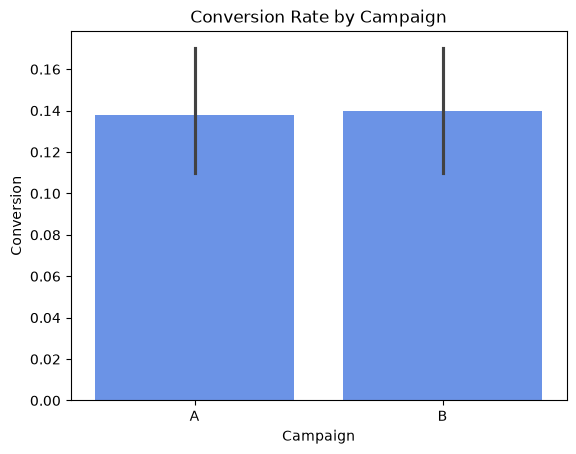

In [25]:
sns.barplot(x='Campaign', y='Conversion', data=df)
plt.title('Conversion Rate by Campaign')
plt.show()


In [26]:
 # Independent T-Test
t_stat, p_value = ttest_ind(
    campaign_a['Conversion'],
    campaign_b['Conversion']
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)


T-Statistic: -0.09131836123684156
P-Value: 0.9272579539840706


In [27]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")


Fail to Reject Null Hypothesis


## Chi-Square Test

In [28]:
contingency_table = pd.crosstab(
    df['Campaign'],
    df['Conversion']
)

contingency_table


Conversion,0,1
Campaign,,
A,431,69
B,430,70


In [29]:

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p)


Chi-Square Statistic: 0.0
P-Value: 1.0


In [30]:

if p < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")


Fail to Reject Null Hypothesis


## ANOVA Test

In [31]:

f_stat, p_value = f_oneway(
    campaign_a['Conversion'],
    campaign_b['Conversion']
)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)


F-Statistic: 0.008339043098982297
P-Value: 0.9272579539840706


In [32]:

if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")


Fail to Reject Null Hypothesis


## Final Conclusion

In [33]:

mean_a = campaign_a['Conversion'].mean()
mean_b = campaign_b['Conversion'].mean()

if mean_a > mean_b:
    print("Campaign A performed better.")
elif mean_b > mean_a:
    print("Campaign B performed better.")
else:
    print("Both campaigns performed equally.")


Campaign B performed better.
